# Lenses

## Lens equation
Lenses are a specific shape of medium that either con- or diverge incoming parallel light rays. This happens because of the refractions on its two circular surfaces. Biconvec lenses converge, biconcave ones diverge.
### Thin lenses
For thin enough lenses we can approximate the two refractions as happening in the same point.
From this and some transformations that can be seen in the theory script, we get the follwoing equation for concave thin lenses:
$$\frac 1 f = \frac 1 {d_o} + \frac 1 {d_i}$$
where $f$ is the focal point's distance to the lens, $d_o$ is the original object's distance and $d_1$ is the images distance.

## Graphing $d_i$ vs. $d_o$
Solving the above equation for $d_o$, we get $$d_o = \frac 1 { \frac 1 f - \frac 1 {d_i}}$$ 
We can avoid the double reciprocals by rewriting this as follows $$= \frac {f d_i} {d_i-f} = \frac {f (d_i -f) +f^2}{d_i-f} = f + \frac {f^2}{d_i-f}$$
In this form we can clearly see that we expect the graph to be hyperbolic, as $d_o \propto \frac 1 {d_i}$.

We can also see that the hyperbole is going to be shifted by f in both x ($f + ...$) and y ($d_i-f$) direction.

In [20]:
import numpy as np

# add code to define arrays with data
#xo = np.array([8.8, 14.6, 12.2, 10, 30.7, 17.7, 13.9, 9, 35, 39, 11, 74.2])
#xl = np.array([33, 29.7, 39.5, 23.5, 42.7, 55.8, 50, 79.9, 79.9, 58, 25, 110.7])
#xi = np.array([49.7, 58, 54, 62.3, 95.6, 58.5, 64, 91.5, 92.4, 78.6, 59.5, 121.3])
xo = np.array([8.8, 14.6, 12.2, 10, 30.7, 13.9, 35, 39, 11])
xl = np.array([33, 29.7, 39.5, 23.5, 42.7, 50, 79.9, 58, 25])
xi = np.array([49.7, 58, 54, 62.3, 95.6, 64, 92.4, 78.6, 59.5])

di = xi - xl
do = xl - xo

ddi = 2 * 0.5
ddo = 2 * 0.2

r^2 = 0.9797
Focal length f = 9.8075 ± 0.0597
t = 164.3251
p-value = 2.2204e-15


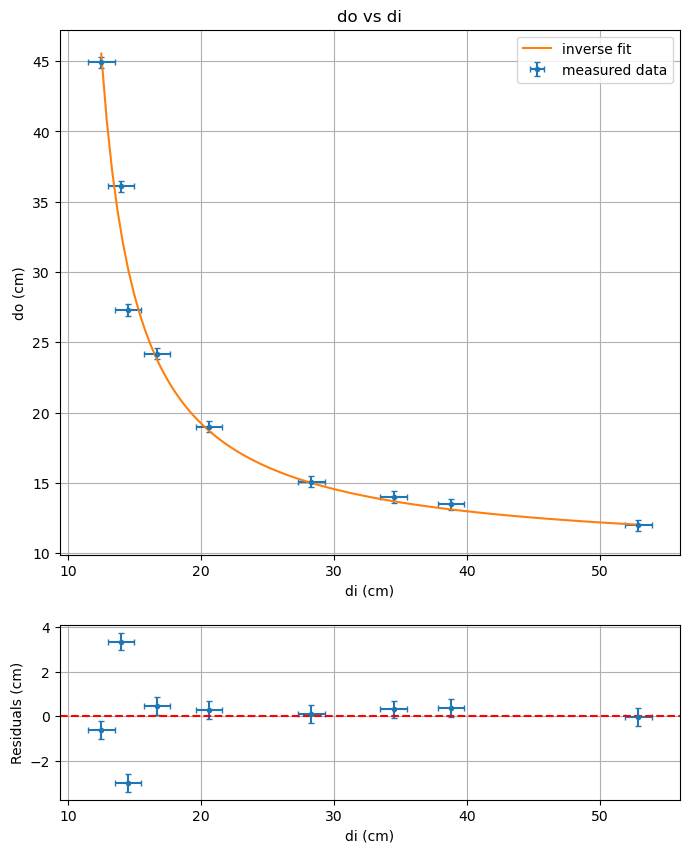

In [25]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def model(x, f):
    return 1/(1/f - 1/x)


# calculate linear fit parameters and their uncertainties
coeff, pcov = curve_fit(model, di, do)
f_lin = coeff[0] 
df_lin = np.sqrt(np.diag(pcov))[0]

# calculate do^2
do_pred = model(di, f_lin)

ss_res = np.sum((do - do_pred) ** 2)              # residual sum of squares
ss_tot = np.sum((do - np.mean(do)) ** 2)          # total sum of squares

r2 = 1 - (ss_res / ss_tot)

print(f"r^2 = {r2:.4f}")

from scipy import stats

# number of data points and parameters
n = len(do)
p = 1  # f and R0

# t-statistic for slope
t_stat = f_lin / df_lin

# degrees of freedom
dof = n - p

# two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), dof))

print(f"Focal length f = {f_lin:.4f} ± {df_lin:.4f}")
print(f"t = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")



# calculate fitted values and residuals
di_range = np.linspace(min(di), max(di), 100)
do_fit = model(di_range, f_lin)

res_lin = do - model(di, f_lin)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(di, do, xerr=ddi, yerr=ddo, fmt='.', capsize=2, label='measured data')
ax1.plot(di_range, do_fit, label='inverse fit')
ax1.set_title('do vs di')
ax1.set_xlabel('di (cm)')
ax1.set_ylabel('do (cm)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(di, res_lin, xerr=ddi, yerr=ddo, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('di (cm)')
ax2.set_ylabel('Residuals (cm)')
ax2.grid(True)
plt.show()


### Discussion
As expected, our data fits a hyperbolic graph, whose asymptotes are shifted by the focal length, very well.

Taking uncertainties in both $d_i$ and $d_o$ in to account, all our data points are visually within the margin of error. This is also confirmed by the high $r^2$ of ~98%

## Graphing $\frac{1}{d_i}$ vs. $\frac{1}{d_o}$
### Graph
For this graph we expect a linear relationship, as $\frac 1 {d_i} = \frac 1 f - \frac 1 {d_o}$. Specifically we expect to see a negative slope, shifted upward by one focal length.
### Refractive index
The task to calculate this seems out of place here and is not mentioned in the exercise sheet, but nevertheless: 

We can rearrange the lensmakers equation for thin lenses $$\frac 1 f = (n-1) \left (\frac 1 {R_1} + \frac 1 {R_2} \right)$$
to find the refractive index: $$n = 1 + \frac 1 {f \left (\frac 1 {R_1} + \frac 1 {R_2} \right) }$$


r^2 = 0.9929
Focal length f = 9.8529 ± 0.0601
Calculated focal length difference = -0.0454 ± 0.0847
t = 163.8077
p-value = 2.2204e-15


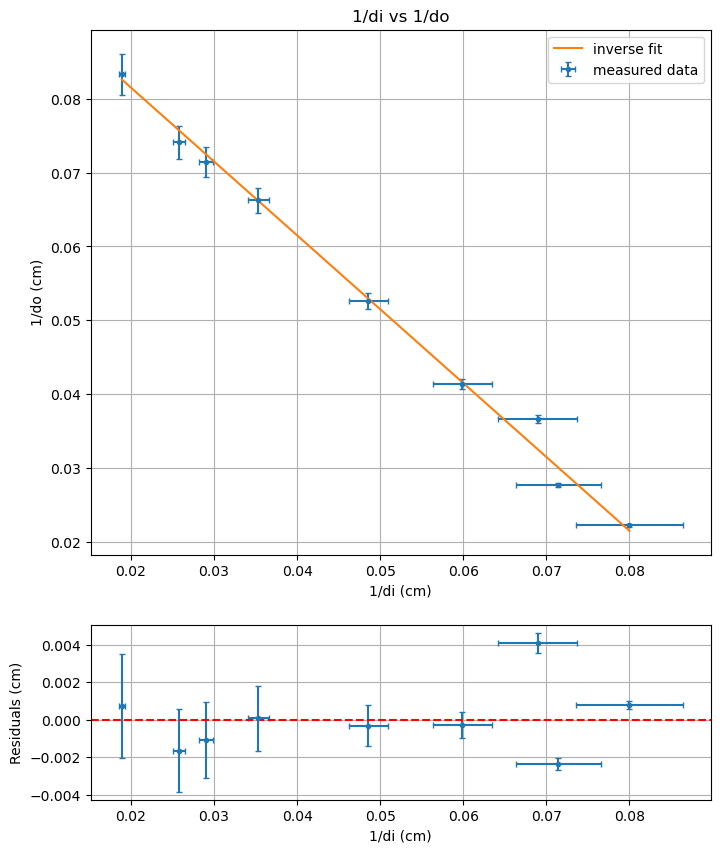

In [26]:

# add code to calculate and print the refractive index here

f_old = f_lin
df_old = df_lin

u = 1/di
du = ddi/(di*di)
v = 1/do
dv = ddo/(do*do)

def model(x, f):
    return 1/f - x

# calculate linear fit parameters and their uncertainties
coeff, pcov = curve_fit(model, u, v)
f_lin = coeff[0] 
df_lin = np.sqrt(np.diag(pcov))[0]

# calculate v^2
v_pred = model(u, f_lin)

ss_res = np.sum((v - v_pred) ** 2)              # residual sum of squares
ss_tot = np.sum((v - np.mean(v)) ** 2)          # total sum of squares

r2 = 1 - (ss_res / ss_tot)

print(f"r^2 = {r2:.4f}")

from scipy import stats

# number of data points and parameters
n = len(v)
p = 1  # f and R0

# t-statistic for slope
t_stat = f_lin / df_lin

# degrees of freevm
vf = n - p

# two-sided p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), vf))

print(f"Focal length f = {f_lin:.4f} ± {df_lin:.4f}")
print(f"Calculated focal length difference = {f_old - f_lin:.4f} ± {np.sqrt(df_lin * df_lin + df_old * df_old):.4f}") # real uncertainty a bit lower as the two uncertainties are correlated, but this should be a good enough approximation
print(f"t = {t_stat:.4f}")
print(f"p-value = {p_value:.4e}")



# calculate fitted values and residuals
u_range = np.linspace(min(u), max(u), 100)
v_fit = model(u_range, f_lin)

res_lin = v - model(u, f_lin)

# plot data, fit, and residuals
fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1, ax2 = ax
ax1.errorbar(u, v, xerr=du, yerr=dv, fmt='.', capsize=2, label='measured data')
ax1.plot(u_range, v_fit, label='inverse fit')
ax1.set_title('1/di vs 1/do')
ax1.set_xlabel('1/di (cm)')
ax1.set_ylabel('1/do (cm)')
ax1.grid(True)
ax1.legend()
ax2.errorbar(u, res_lin, xerr=du, yerr=dv, fmt='.', capsize=2)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('1/di (cm)')
ax2.set_ylabel('Residuals (cm)')
ax2.grid(True)
plt.show()

### Discussion
#### Graph
Once again, our data matches the expected graph very well, with an $r^2$ of >99% and all data points being within the margin of error.

The fitted focal lengths also only differ within the margin of error.
#### Refractive Index
As we did not know we needed to measure the lenses radii, we cannot calculate the actual refractive index.

## Graphing $d_i \cdot d_o$ vs. $d_i + d_o$

*Describe what you expect.*

In [ ]:
# add code to graph the data and fit here (with residual plot)

### Discussion
*Derive the focal length from the fit parameters of the three graphs and discuss the results*

In [62]:
# add code to calculate and print the refractive index here

## Two Lenses

*Calculate the predicted position and size of the image and compare with experimental data*

In [64]:
# add data and code here